In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/trained_dataset.h5")
  # change path if needed

In [ ]:
class_names = ['blade', 'cutter', 'screwdriver', 'spanner']

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def take_photo(filename='photo.jpg'):
    js = Javascript('''
        async function takePhoto() {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capture';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          await new Promise(resolve => capture.onclick = resolve);
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', 0.8);
        }
        takePhoto();
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

take_photo()

<IPython.core.display.Javascript object>

'photo.jpg'

In [ ]:
img = cv2.imread('photo.jpg')
img = cv2.resize(img, (224, 224))
img = img / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)
print("Prediction:", prediction)
print("Class:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prediction: [[7.7398431e-01 1.7270784e-08 2.2599663e-01 1.9096929e-05]]
Class: 0


In [ ]:
import cv2
import numpy as np

img = cv2.imread('photo.jpg')     # image from camera
img = cv2.resize(img, (224,224))  # same size as training
img = img / 255.0                 # normalize
img = np.expand_dims(img, axis=0)

In [ ]:
prediction = model.predict(img)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[7.7398431e-01 1.7270784e-08 2.2599663e-01 1.9096929e-05]]


In [ ]:
index = np.argmax(prediction)
confidence = prediction[0][index] * 100

print("Tool Name :", class_names[index])
print("Confidence:", round(confidence,2), "%")

Tool Name : blade
Confidence: 77.4 %


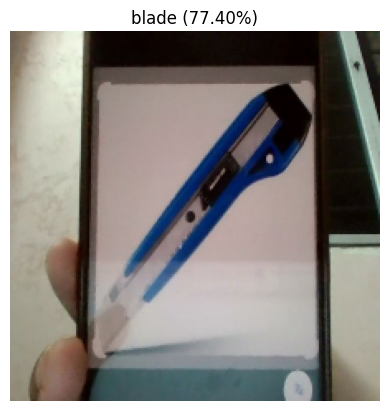

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate index and confidence here to ensure they are defined
index = np.argmax(prediction)
confidence = prediction[0][index] * 100

plt.imshow(cv2.cvtColor((img[0]*255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title(f"{class_names[index]} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def take_photo(filename='photo.jpg'):
    js = Javascript('''
        async function takePhoto() {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capture';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          await new Promise(resolve => capture.onclick = resolve);
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', 0.8);
        }
        takePhoto();
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

take_photo()

<IPython.core.display.Javascript object>

AttributeError: 'NoneType' object has no attribute 'split'

In [ ]:
index = np.argmax(prediction)
confidence = prediction[0][index] * 100

print("Tool Name :", class_names[index])
print("Confidence:", round(confidence,2), "%")

Tool Name : blade
Confidence: 58.87 %


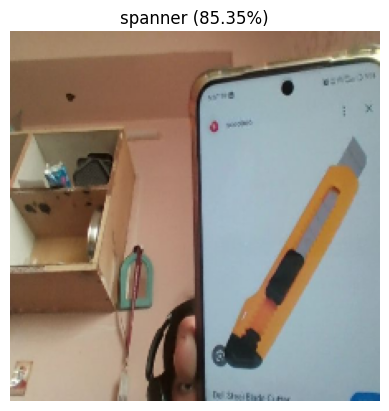

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor((img[0]*255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title(f"{class_names[index]} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

In [ ]:
model.save('tool_cnn_model.h5')

In [ ]:
from google.colab import files
files.download('tool_cnn_model.h5')

FileNotFoundError: Cannot find file: tool_cnn_model.h5

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/trained_dataset.h5') # Corrected path
class_names = ['blade', 'cutter', 'screwdriver', 'spanner']

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    img = cv2.resize(frame, (224,224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    index = np.argmax(pred)
    confidence = pred[0][index] * 100

    cv2.putText(frame,
        f"{class_names[index]} ({confidence:.1f}%)",
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,0), 2)

    cv2.imshow("Live Tool Detection", frame)

    if cv2.waitKey(1) == 27:  # ESC to exit
        break

cap.release()
cv2.destroyAllWindows()

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def take_photo(filename='photo.jpg'):
    js = Javascript('''
        async function takePhoto() {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capture';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          await new Promise(resolve => capture.onclick = resolve);
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', 0.8);
        }
        takePhoto();
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

print('Click the capture button in the pop-up window to take a photo.')
try:
  filename = take_photo()
  print(f'Saved to {filename}')
except Exception as err:
  print(str(err))
  print('Please grant camera permissions and try again. You might need to refresh the page.')

Click the capture button in the pop-up window to take a photo.


<IPython.core.display.Javascript object>

Saved to photo.jpg


In [ ]:
img = cv2.imread(filename)     # Load the image taken from the camera
img = cv2.resize(img, (224,224))  # Resize to the input size of the model
img = img / 255.0                 # Normalize pixel values
img = np.expand_dims(img, axis=0) # Add batch dimension

prediction = model.predict(img)

index = np.argmax(prediction)
confidence = prediction[0][index] * 100

print("Tool Name :", class_names[index])
print("Confidence:", round(confidence,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Tool Name : spanner
Confidence: 61.05 %
